# Recurrent neural network

The purpose of this notebook is this notebook is to classify reviews and predict whether comments are "negative" or "positive" using recurrent neural network.



## Load dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
import seaborn as sns
plt.style.use('ggplot')

In [22]:
rows = []

with open("reviews_1000.csv", encoding="utf-8") as f:
    for line in f:
        line = line.rstrip("\n").strip()

        # Ignorer les lignes vides
        if not line:
            continue

        # Vérifier qu'il y a au moins une virgule
        if "," not in line:
            continue

        try:
            review, sentiment = line.rsplit(",", 1)
            rows.append([review, sentiment])

        except ValueError:
            continue

reviews_df = pd.DataFrame(rows, columns=["review", "sentiment"])
reviews_df = reviews_df.iloc[1:]
reviews_df.head()

,review,sentiment
1,One of the other reviewers has mentioned that ...,positive
2,"""A wonderful little production. <br /><br />Th...","positive"""
3,"""I thought this was a wonderful way to spend t...","positive"""
4,Basically there's a family where a little boy ...,negative
5,"""Petter Mattei's """"Love in the Time of Money""""...","positive"""


## Data preprocessing

In [23]:
## Vérification de valeurs nulles
reviews_df.isnull().sum()

,0
review,0
sentiment,0


In [24]:
reviews_df.sentiment.unique()

array(['positive', 'positive"', 'negative', 'negative"'], dtype=object)

Difference in proportion: -25

Number of positive reviews: 255
Number of negative reviews: 230


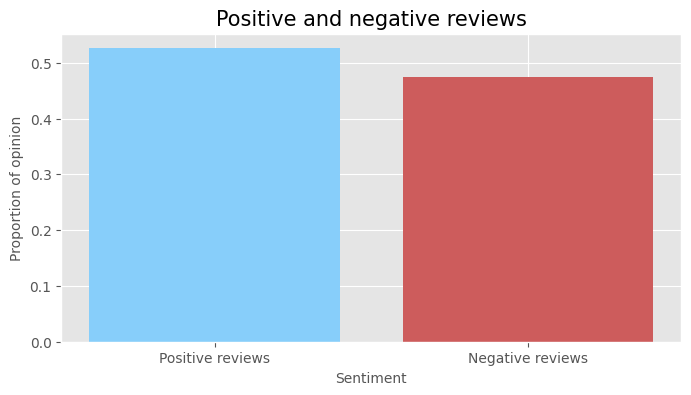

In [25]:
## Verification of the distribution of both classes

positive_df = reviews_df[reviews_df['sentiment'] == 'positive']
negative_df = reviews_df[reviews_df['sentiment'] == 'negative']

total_len = len(positive_df) + len(negative_df)
plt.figure(figsize=(8, 4))
plt.bar('Positive reviews', len(positive_df) / total_len, color='lightskyblue')
plt.bar('Negative reviews', len(negative_df) / total_len, color='indianred')
plt.title('Positive and negative reviews', size=15)
plt.xlabel('Sentiment', size=10)
plt.ylabel("Proportion of opinion", size=10)

print('Difference in proportion:',len(negative_df)-len(positive_df))
print("\nNumber of positive reviews:",len(positive_df))
print("Number of negative reviews:",len(negative_df))

We have a dataset that is balanced in its proportion of negative and positive reviews.

### Cleaning

We will put the text in lowercase, remove punctuations and numbers, delete stop words, apply lemmatization, separate into tokens. These steps are used to reduce the complexity of the dimensionality of the text. In addition, we will preserve the contractions "n't" in "not" to keep the negative forms that are important in the analysis of feelings.

In [26]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer as wnl
from bs4 import BeautifulSoup


nltk.download('punkt') #this tokenizer divides a text into a list of sentences
nltk.download('wordnet') #it is a large word database of English Nouns, Adjectives, Adverbs and Verbs
nltk.download('stopwords') #commonly used word
nltk.download('omw-1.4') #provides access to open wordnets in a variety of languages, all linked to a collaborative Interlingual Index

stopwords = stopwords.words('english')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [41]:
clean_data = []
for i in range(0, len(reviews_df)):
  row = reviews_df['review'].iloc[i]

  # delete <br>
  row = re.sub(r'(?:<br\s*/?>\s*)+', ' ', row, flags=re.IGNORECASE)

  # preserve negative forms
  row = re.sub("n't", " not", row)

  # remove extra spaces
  row = re.sub(' +', ' ', row)

  # delete every pontuations except letters
  row = re.sub('[^a-zA-Z!]', ' ', row)


  ## apply lowercase
  row = row.lower()

  ## tokens
  row = row.split()
  #print(row)

  ## delete stop words
  row = [(word) for word in row if not word in set(stopwords)]

  ##  lemmatization
  row = [wnl().lemmatize(word) for word in row]
  #print(row)

  clean_data.append(' '.join(row))


## Split and process data

In [28]:
X = reviews_df["review"]
y = reviews_df["sentiment"]

## separation of data in test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

#print(y_test)

### Labels correction


In [29]:
y_train = y_train.astype(str).str.replace('"', '')
y_test = y_test.astype(str).str.replace('"', '')

#print(y_train.unique())
sentiment_mapping = {'negative': 0, 'positive': 1}
y_train = y_train.map(sentiment_mapping)
y_test = y_test.map(sentiment_mapping)

print(y_test)

if y_train.isnull().any():
    print(f"Warning: Unmapped labels found in y_train: {y_train[y_train.isnull()].unique()}")
if y_test.isnull().any():
    print(f"Warning: Unmapped labels found in y_test: {y_test[y_test.isnull()].unique()}")

723    1
78     0
878    0
614    0
904    0
      ..
151    1
300    1
240    0
982    0
436    1
Name: sentiment, Length: 200, dtype: int64


### Tokenization

- the OOV option: when predicting there may be words never seen before during training, they will be ignored.


In [30]:
max_vocab = 20000
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

### Converting text into digital vectors

In [31]:
X_train = tokenizer.texts_to_sequences(X_train)
X_test  = tokenizer.texts_to_sequences(X_test)

### Padding

We do the padding so that all the sequences have the same length.

In [32]:
max_len = 256
X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post')


## Construction of the RNN model

We build a sequential model where the layers are stacked in order. Each layer takes the output of the preceding one as input.
- embedding is used to turn tokens into dense vectors. Each word will be represented by a vector of 128 dimensions.
- we set up a Long Short-Term Memor (LSTM), which will keep in mind the important information.
- we stack two LSTMs to better understand the information. The first layer will have a greater capacity to learn details, and the second will filter out the most important information.
- the model will have a fully connected dense layer of 64 neurons.
- dropout serves us to avoid over-learning.


In [33]:
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


#model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [35]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=30, shuffle=True, callbacks=[early_stop])


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 588ms/step - accuracy: 0.5117 - loss: 0.6949 - val_accuracy: 0.4437 - val_loss: 0.6978
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 585ms/step - accuracy: 0.5243 - loss: 0.6846 - val_accuracy: 0.4437 - val_loss: 0.7068
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 606ms/step - accuracy: 0.7418 - loss: 0.5830 - val_accuracy: 0.6438 - val_loss: 0.6579
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 587ms/step - accuracy: 0.9218 - loss: 0.2366 - val_accuracy: 0.6500 - val_loss: 0.7678
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 584ms/step - accuracy: 0.9859 - loss: 0.0596 - val_accuracy: 0.6500 - val_loss: 1.0736


## Visualization and Evaluation




### Visualization of training over time


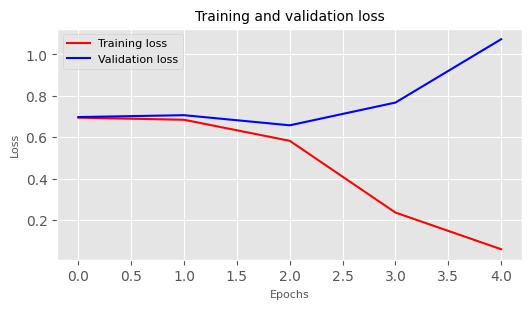

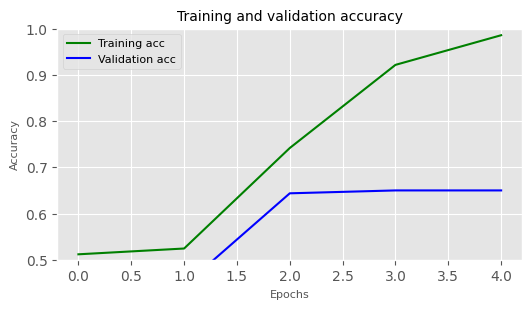

In [36]:
history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = history.epoch

plt.figure(figsize=(6,3))
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss', size=10)
plt.xlabel('Epochs', size=8)
plt.ylabel('Loss', size=8)
plt.legend(prop={'size': 8})
plt.show()

plt.figure(figsize=(6,3))
plt.plot(epochs, acc, 'g', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy', size=10)
plt.xlabel('Epochs', size=8)
plt.ylabel('Accuracy', size=8)
plt.legend(prop={'size': 8})
plt.ylim((0.5,1))
plt.show()

#### Observations

- with validation_split of 0.1:

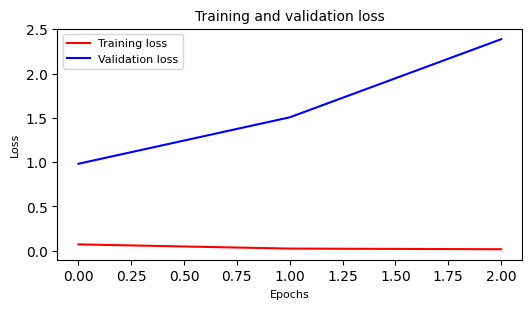
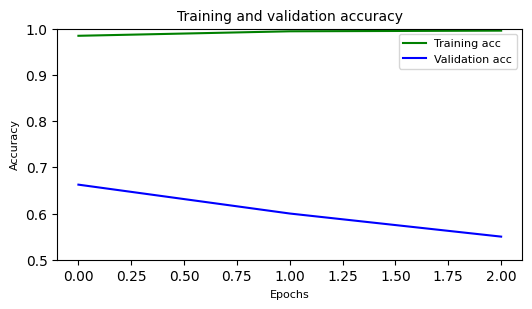
- with validation_split of 0.2 :

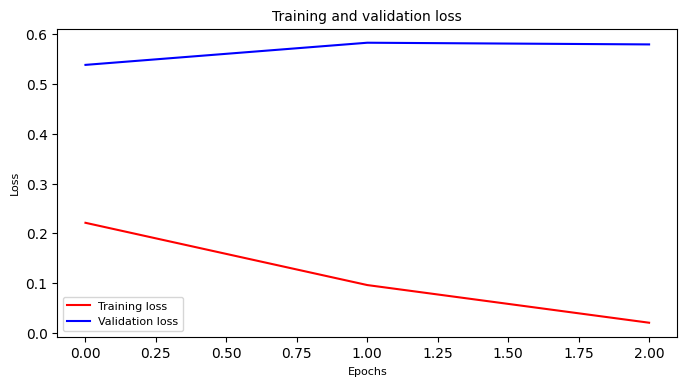
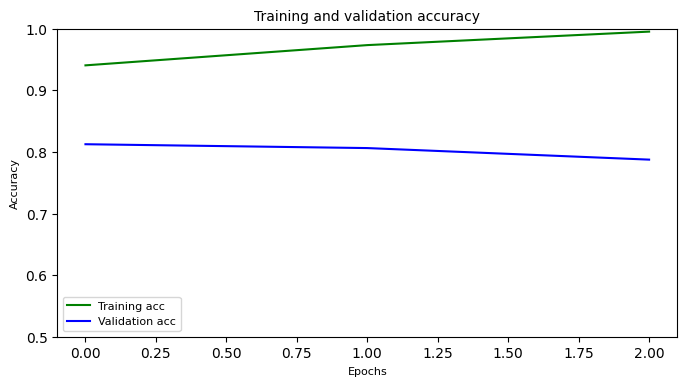

The model quickly overlears training data. The increasing gap between the drive and validation curves shows an overfitting.

- 0.3:

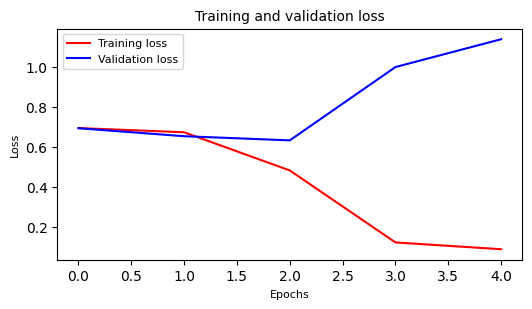

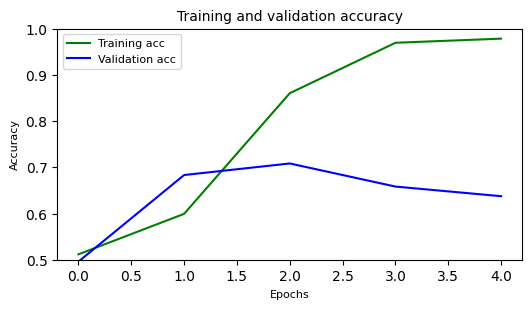

### Evaluation of the test set

In [37]:
model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.6700 - loss: 0.6629


[0.6629360914230347, 0.6700000166893005]

In [38]:
pred = model.predict(X_test)

binary_predictions = []

for i in pred:
    if i >= 0.5:
        binary_predictions.append(1)
    else:
        binary_predictions.append(0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step


In [39]:
print('Accuracy on testing set:', accuracy_score(binary_predictions, y_test))
print('Precision on testing set:', precision_score(binary_predictions, y_test))
print('Recall on testing set:', recall_score(binary_predictions, y_test))

Accuracy on testing set: 0.67
Precision on testing set: 0.7978723404255319
Recall on testing set: 0.6147540983606558


### Matrice de confusion

[Text(0, 0.5, '0'), Text(0, 1.5, '1')]

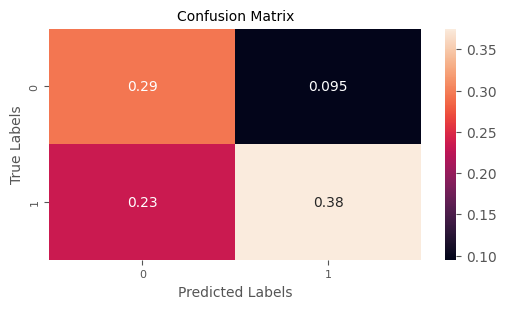

In [40]:
matrix = confusion_matrix(binary_predictions, y_test, normalize='all')
plt.figure(figsize=(6, 3))
ax= plt.subplot()
sns.heatmap(matrix, annot=True, ax = ax)

# labels, title and ticks
ax.set_xlabel('Predicted Labels', size=10)
ax.set_ylabel('True Labels', size=10)
ax.set_title('Confusion Matrix', size=10)
ax.xaxis.set_ticklabels([0,1], size=8)
ax.yaxis.set_ticklabels([0,1], size=8)

The model gets about 73% of correct predictions.
It is slightly better at predicting positive reviews (39%) than negative reviews (34%).
However, confusion is still important: 20% of positive reviews are misclassified as negative, and 8% of negative reviews are misclassified as positive.
This shows that the model still struggles to clearly separate the two feelings, probably due to a lack of model ability, or a training that may be insufficient.